In [285]:
!pip install python-dotenv langchain langchain-core langchain-community langchain-google-genai chromadb langchain-text-splitters beautifulsoup4 sentence-transformers einops langchainhub langsmith faiss-cpu pydantic rank_bm25 sentence-transformers 
!pip install langchain-google-vertexai

In [286]:
# In terminal google cloud vertex ai setup
# !curl https://sdk.cloud.google.com | bash
# !gcloud auth application-default login

## Declaration

In [287]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
import transformers
import json
import numpy as np
import os
import warnings
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import List
from langchain_community.retrievers import BM25Retriever
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from typing import TypedDict, List
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import time
import vertexai
from vertexai.generative_models import GenerativeModel


load_dotenv()
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
warnings.filterwarnings("ignore")




class QueryOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class QueryOptimizerOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class GraphState(TypedDict):
    query: str
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str
    documents: List[Document]
    answer: str
    iteration: int
    retrieval_feedback: dict
    doc_scores: List[float]


### Models

In [288]:

# llm_compression = ChatGoogleGenerativeAI( model="gemini-2.5-flash" )
# llm = ChatGoogleGenerativeAI( model="gemini-3-flash-preview" )
# structured_llm = llm.with_structured_output(QueryOutput)

vertexai.init(project="pleet-d8210", location="global")
model = GenerativeModel("gemini-3-flash-preview")
compression_model = GenerativeModel("gemini-2.5-flash")
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
embeddings = HuggingFaceEmbeddings(model_name="nomic-ai/nomic-embed-text-v1",model_kwargs={"trust_remote_code": True})


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8544.86it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
<All keys matched successfully>


In [289]:
import random


def llm_invoke(prompt: str, model_instance=model):
    try:
        response = model_instance.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        raise e


def safe_llm_invoke_vertex(prompt, model_instance, retries=5):
    import random, time

    last_error = None

    for i in range(retries):
        try:
            return llm_invoke(prompt, model_instance)
        except Exception as e:
            last_error = e
            wait_time = (2 ** i) + random.uniform(0, 1)
            print(f"[Retry {i+1}] Waiting {wait_time:.2f}s →", repr(e))
            time.sleep(wait_time)

    raise last_error
    

## Query Rewritting & Expansion

* User Query  ->  Query Rewriting  ->  Step-Back Query  ->  Query Expansion


| Step      | Why                                      |
| --------- | ---------------------------------------- |
| Rewrite   | cleans the query and removes ambiguity   |
| Step-back | captures **higher-level concept**        |
| Expansion | generates **multiple search variations** |


In [299]:
optimizer_prompt = f"""
You are an expert query optimizer. Return ONLY JSON.

User Query: {query}

Perform:
1. Rewrite query
2. Generate 3 variations
3. Generate step-back query

Return JSON:
{{
"rewritten_query": "...",
"expanded_queries": ["...", "...", "...", "..."],
"step_back_query": "..."
}}
"""

def query_intelligence_node(state):

    iteration = state.get("iteration", 0)

    # PASS 1 (normal)
    if iteration == 0:
        query = state["query"]

        prompt = optimizer_prompt.invoke({
            "query": query
        })

    # PASS 2 (feedback-driven)
    else:
        feedback = state.get("retrieval_feedback", {})

        snippets = [
            doc.page_content[:200] 
            for doc in state.get("documents", [])[:2]
        ]

        refined_query = f"""
            Previous retrieval failed.

            Reason: {feedback.get("reason")}
            Max Score: {feedback.get("max_score")}
            Avg Score: {feedback.get("avg_score")}

            The following snippets were retrieved but are NOT relevant:
            {chr(10).join(snippets)}

            IMPORTANT:
            - These snippets are incorrect or irrelevant
            - Do NOT base your query on them
            - Use them only to understand what went wrong

            Original Query:
            {state["query"]}

            Previous Rewritten Query:
            {state.get("rewritten_query")}

            Your task:
            - Identify why retrieval failed
            - Fix the query without drifting away from user intent
            - Preserve original intent strictly
            - Improve specificity and keywords
        """
        
        prompt = optimizer_prompt.invoke({
            "query": refined_query
        })

    raw_output = safe_llm_invoke_vertex(prompt, model)
    try:
        parsed = json.loads(raw_output)
        result = QueryOutput(**parsed)
    except Exception as e:
        print("Parsing failed:", raw_output)
        raise e

    print("Rewritten_query",result.rewritten_query)
    print("Expanded_queries",result.expanded_queries)
    print("Step_back_query",result.step_back_query)

    return {
        "rewritten_query": result.rewritten_query,
        "expanded_queries": result.expanded_queries,
        "step_back_query": result.step_back_query
    }




NameError: name 'query' is not defined

VECTOR-DB, EMBEDDINGS & INGESTION

In [291]:

documents = [
    Document(page_content="RAG systems retrieve documents before generation."),
    Document(page_content="Faithfulness measures whether answers are grounded in retrieved documents."),
    Document(page_content="Query expansion improves recall in retrieval systems."),
]

vectorstore = Chroma.from_documents(
    documents=documents,
    collection_name="verirag-chroma",
    embedding=embeddings,
)

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5

RETRIEVER

In [292]:
# Retrieve top 5 results from both BM25 and Vector retrievers, then deduplicate results
def hybrid_retrieve_node(state):
    queries = (
        [state["rewritten_query"]] +
        state["expanded_queries"] +
        [state["step_back_query"]]
    )

    all_docs = []
    print("----------------------------")
    for q in queries:
        print("Query: ",q)
        all_docs.extend(bm25_retriever.invoke(q))
        all_docs.extend(vector_retriever.invoke(q))
        print(all_docs)
        
    print("----------------------------")
    # Deduplicate
    unique_docs = list({doc.page_content: doc for doc in all_docs}.values())

    return {"documents": unique_docs}

## Cross Encoder & Re-Ranking

In [293]:
# Rerank retrieved documents using cross-encoder, normalised scores and filter out low-relevance docs based on a threshold
def rerank_and_filter_node(state):

    docs = state.get("documents", [])
    query = state["query"]

    if not docs:
        return {
            "documents": [],
            "answer": "I don't know",
            "retrieval_feedback": {"reason": "no_docs"}
        }

    pairs = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    scores = 1 / (1 + np.exp(-scores))

    doc_scores = list(zip(docs, scores))
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    top_docs = doc_scores[:5]
    top_scores = [score for _, score in top_docs]
    max_score = max(top_scores)
    avg_score = sum(top_scores) / len(top_scores)
    print(top_scores, max_score, avg_score)
    print("----------------------------")

    threshold = 0.6

    if max_score < threshold:
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores,
            "retrieval_feedback": {
                "reason": "low_relevance",
                "max_score": float(max_score),
                "avg_score": float(avg_score)
            }
        }
    print("rerank: ",[doc for doc, _ in top_docs])
    print("--------------------------------------")
    return {
        "documents": [doc for doc, _ in top_docs],
        "doc_scores": top_scores
    }

In [294]:
def Retry_decision_logic(state):

    iteration = state.get("iteration", 0)
    max_iterations = 2

    if state.get("answer") == "I don't know" and iteration >= max_iterations:
        return "generate"

    # If no docs → retry
    if not state.get("documents") and iteration < max_iterations:
        return "retry"

    return "generate"

def Refine_query_node(state):
    return {
        "iteration": state.get("iteration", 0) + 1
    }

In [ ]:
def extract_text(response):
    content = response.content

    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content]).strip()
    
    return content.strip()


from sklearn.metrics.pairwise import cosine_similarity

def compress_documents_node(state):

    query = state["query"]
    docs = state.get("documents", [])[:3]

    if not docs:
        return {"documents": []}

    # Embed query once
    query_embedding = embeddings.embed_query(query)

    compressed_docs = []

    total_original_tokens = 0
    total_compressed_tokens = 0

    for doc in docs:

        text = doc.page_content

        # Rough token count (interview acceptable approximation)
        total_original_tokens += len(text.split())

        # Step 1: sentence splitting (simple but effective)
        sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 10]

        if not sentences:
            compressed_docs.append(doc)
            continue

        # Step 2: embed sentences
        sentence_embeddings = embeddings.embed_documents(sentences)

        # Step 3: similarity scoring
        scores = cosine_similarity(
            [query_embedding],
            sentence_embeddings
        )[0]

        # Step 4: pick top-k sentences
        top_k = min(3, len(sentences))

        top_indices = np.argsort(scores)[-top_k:]
        top_indices = sorted(top_indices)  # preserve order

        selected_sentences = [sentences[i] for i in top_indices]

        compressed_text = ". ".join(selected_sentences)

        total_compressed_tokens += len(compressed_text.split())

        compressed_docs.append(Document(page_content=compressed_text))

    # 🔥 LOGGING (THIS is what impresses interviewers)
    print("📉 Compression Stats:")
    print(f"Original tokens: {total_original_tokens}")
    print(f"Compressed tokens: {total_compressed_tokens}")

    if total_original_tokens > 0:
        reduction = 1 - (total_compressed_tokens / total_original_tokens)
        print(f"Reduction: {reduction:.2%}")

    return {"documents": compressed_docs}





## GENERATION

In [ ]:
generation_prompt = ChatPromptTemplate.from_template(
"""
    You are a strict assistant.

    Answer ONLY using the provided context.
    If the answer is not clearly present, say "I don't know".

    Question:
    {query}

    Context:
    {context}

    Answer:
"""
)
def generate_answer_node(state):

    # If reranker already decided to stop
    if state.get("answer") == "I don't know":
        return {"answer": "I don't know"}

    docs = state.get("documents", [])

    if not docs:
        return {"answer": "I don't know"}

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = generation_prompt.format(
        query=state["query"],
        context=context
    )

    answer = safe_llm_invoke_vertex(prompt, model)
    return {"answer": answer}





## Graph Compliation

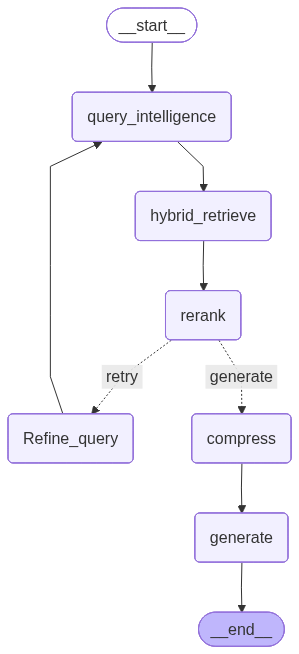

In [297]:
builder = StateGraph(GraphState)

builder.add_node("query_intelligence", query_intelligence_node)
builder.add_node("hybrid_retrieve", hybrid_retrieve_node)
builder.add_node("rerank", rerank_and_filter_node)
builder.add_node("Refine_query", Refine_query_node)
builder.add_node("generate", generate_answer_node)
builder.add_node("compress", compress_documents_node)

builder.set_entry_point("query_intelligence")

builder.add_edge("query_intelligence", "hybrid_retrieve")
builder.add_edge("hybrid_retrieve", "rerank")
builder.add_edge("compress", "generate")


builder.add_conditional_edges(
    "rerank",
    Retry_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "compress"
        # "generate": "generate"
    }
)

builder.add_edge("Refine_query", "query_intelligence")
builder.add_edge("generate", END)

graph = builder.compile()

from IPython.display import Image, display # type: ignore
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Inferencing RAG

In [298]:
result = graph.invoke({
    # "query": "How do we measure faithfulness in computer terminal?"
    "query": "How do we measure faithfulness in RAG?",
    "iteration": 0
})
print(result["answer"])

# compression is changing the docs printed below, ig need to change the prompt for compression

[Retry 1] Waiting 1.37s → TypeError('Unexpected value type: messages=[SystemMessage(content=\'You are an expert query optimizer. Return ONLY JSON.\', additional_kwargs={}, response_metadata={}), HumanMessage(content=\'\\n        User Query:\\n        How do we measure faithfulness in RAG?\\n\\n        Perform:\\n        1. Rewrite query\\n        2. Generate 3 variations\\n        3. Generate step-back query\\n\\n        Return JSON:\\n\\n        {\\n        "rewritten_query": "...",\\n        "expanded_queries": ["...", "...", "...", "..."],\\n        "step_back_query": "..."\\n        }\\n    \', additional_kwargs={}, response_metadata={})]')
[Retry 2] Waiting 2.87s → TypeError('Unexpected value type: messages=[SystemMessage(content=\'You are an expert query optimizer. Return ONLY JSON.\', additional_kwargs={}, response_metadata={}), HumanMessage(content=\'\\n        User Query:\\n        How do we measure faithfulness in RAG?\\n\\n        Perform:\\n        1. Rewrite query\\n      

TypeError: Unexpected value type: messages=[SystemMessage(content='You are an expert query optimizer. Return ONLY JSON.', additional_kwargs={}, response_metadata={}), HumanMessage(content='\n        User Query:\n        How do we measure faithfulness in RAG?\n\n        Perform:\n        1. Rewrite query\n        2. Generate 3 variations\n        3. Generate step-back query\n\n        Return JSON:\n\n        {\n        "rewritten_query": "...",\n        "expanded_queries": ["...", "...", "...", "..."],\n        "step_back_query": "..."\n        }\n    ', additional_kwargs={}, response_metadata={})]